Capstone build v3:

Start with entropy calculations for dataset created and provided.

Imports / libs and tools/testing metrics to be placed at cell one.

1. Entropy funtion build
2. Entropy calculation values - mapped direct for capstone_clean/dirty.
3. One for each of the tampered files.
4. Load dataset - manual model no current file entropy.
5. Inspection of rows to confirm sample IDs
6. Application of file entropy to dataset
7. Save amended dataset with entropy in place
8. Model preperations:
9. Train / Test / Split
10. Train model
11. Evaluation

Time permitting other exacutables:

Create lite version of cyber kiosk

*   Pull dataset using digital forensic methods (current dataset was hand made)
*   Provide visuals as much as possible
*   Create GUI

In [ ]:
#Imports Keep All Import Here!!!

#Entropy Calculations
import math
from collections import Counter

#Number / Arrays
import numpy as np

#Tables / Dataframes
import pandas as pd

#Presentation of Data
import matplotlib.pyplot as plt

#File Handling
import os

#Paste CSV Text Directly into Python
from io import StringIO

#SKlearn Imports
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

#Evaluation
from sklearn.metrics import (
    confusion_matrix,
    precision_score,
    recall_score,
    average_precision_score,
    classification_report
)

In [ ]:
#Entropy Function

def calculate_entropy(file_path):
  with open(file_path, "rb") as f:
    data = f.read()
  if not data:
    return 0.0

  counter = Counter(data)
  length = len(data)

  entropy = -sum((count / length) *math.log2(count / length) for count in counter. values())
  return entropy

In [ ]:
#Run Across Clean & Dirty Files
results = []

folders = {
    "clean": "Clean_Files_Pulled",
    "dirty": "Dirty_Files_Pulled"
}

for label, folder in folders.items():
  for file in os.listdir(folder):
    file_path = os.path.join(folder, file)

    if os.path.isfile(file_path):
      entropy = calculate_entropy(file_path)

      results.append({
          "file_name": file,
          "dataset": label,
          "entropy_score": round(entropy, 4),
          "high_entropy_flag": 1 if entropy >= 7.5 else 0

      })

#Show Results
entropy_df = pd.DataFrame(results)
entropy_df


,file_name,dataset,entropy_score,high_entropy_flag
0,74141-Orange Frog.png.png,clean,7.9886,1
1,Animation.html.html,clean,4.3712,0
2,74137-Kermit the Frog.png.png,clean,7.9880,1
3,74135-Green frog.png.png,clean,7.9934,1
4,74145-Save the frogs.png.png,clean,7.9935,1
5,74133-Glass frog.png.png,clean,7.9917,1
6,TM02835233[[fn=Text Sidebar (Annual Report Red...,clean,6.4233,0
7,All work and no play make Jack a dull boy.docx...,clean,7.2076,0
8,MpDefenderCoreService.exe.exe,clean,-0.0000,0
9,74129-Drama Frog.png.png,clean,7.9888,1


In [ ]:
#Save Entropy Output
entropy_df.to_csv("entropy_results.csv", index=False)

In [ ]:
#Merge Entropy With Full Dataset
main_df = pd.read_csv("Capstone_Final_Dataset.csv")
entropy_df = pd.read_csv("entropy_results.csv")

#Drop Old Empty Entropy Columns
main_df = main_df.drop(columns=["entropy_score", "high_entropy_flag"], errors="ignore")

#Clean File Names
main_df["file_name"] = main_df["file_name"].str.strip().str.lower()
entropy_df["file_name"] = entropy_df["file_name"].str.strip().str.lower()

#Merge
merged_df = main_df.merge(
    entropy_df[["file_name", "entropy_score", "high_entropy_flag"]],
    on="file_name",
    how="left"
)

#Fill Missing Values
merged_df["entropy_score"] = merged_df["entropy_score"].fillna(0)
merged_df["high_entropy_flag"] = merged_df["high_entropy_flag"].fillna(0)

#Convert to integers
merged_df["high_entropy_flag"] = merged_df["high_entropy_flag"].astype(int)

#Checking Results
merged_df.head()

,source_vm,artefact_type,file_name,file_path,file_size,created_time,modified_time,accessed_time,deleted_flag,hidden_flag,extension_mismatch,timestamp_anomaly,suspicious_tool_trace,encryption_indicator,notes,label,entropy_score,high_entropy_flag
0,clean,office_document,tm02835233[[fn=text sidebar (annual report red...,0,0,0,0,0,0,0,0,0,0,0,Normal office documents clean baseline,0,0.0,0
1,clean,office_document,all work and no play make jack a dull boy.docx,0,0,0,0,0,0,0,0,0,0,0,Normal office documents clean baseline,0,0.0,0
2,clean,office_document,mmw_recorded_2025_26_quarter_1.xlsx,0,0,0,0,0,0,0,0,0,0,0,Normal office documents clean baseline,0,0.0,0
3,clean,office_document,wizard_frog.docx,0,0,0,0,0,0,0,0,0,0,0,Normal office documents clean baseline,0,0.0,0
4,clean,deleted_file,syncengine-2026-04-14.1049.8492.1.odl,0,0,0,0,0,1,0,0,0,0,0,Normal deleted/cashe artefact in clean baseline,0,0.0,0


In [ ]:
#Save Current Progress
merged_df.to_csv("Capstone_Final_Dataset_with_entropy.csv", index=False)

In [ ]:
#Model Preperation
df = pd.read_csv("Capstone_Final_Dataset_with_entropy.csv")

#Drop Text Columns Not Used by Model
model_df = df.drop(columns=["file_name", "file_path", "notes"], errors="ignore")

#Encode Categorical Columns
model_df["source_vm"] = model_df["source_vm"].map({"clean": 1})

le = LabelEncoder()
model_df["artefact_type"] = le.fit_transform(model_df["artefact_type"].astype(str))

#Features & Labels
x = model_df.drop(columns=["label"])
y = model_df["label"]

#Train Test Split
x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

#Train model
model = RandomForestClassifier(random_state=42)
model.fit(x_train, y_train)

#Predictions
y_pred = model.predict(x_test)
y_prob = model.predict_proba(x_test)[:, 1]

print("Model Trained Successfully")

Model Trained Successfully


In [ ]:
print("Canfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred))

Canfusion Matrix:
[[14  3]
 [ 0 10]]

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.82      0.90        17
           1       0.77      1.00      0.87        10

    accuracy                           0.89        27
   macro avg       0.88      0.91      0.89        27
weighted avg       0.91      0.89      0.89        27



In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

precision = precision_score(y_test, y_pred, zero_division=0)
recall = recall_score(y_test, y_pred, zero_division=0)
fnr = fn / (fn + tp) if (fn + tp) > 0 else 0
npv = tn / (tn + fn) if (tn + fn) > 0 else 0
pr_auc = average_precision_score(y_test, y_prob)

print("Confusion Matrix:")
print(cm)
print()
print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"False Negative Rate (FNR): {fnr:.3f}")
print(f"Negative Predictive Value (NVP): {npv:.3f}")
print(f"PR-AUC: {pr_auc:.3f}")

Confusion Matrix:
[[14  3]
 [ 0 10]]

Precision: 0.769
Recall: 1.000
False Negative Rate (FNR): 0.000
Negative Predictive Value (NVP): 1.000
PR-AUC: 1.000


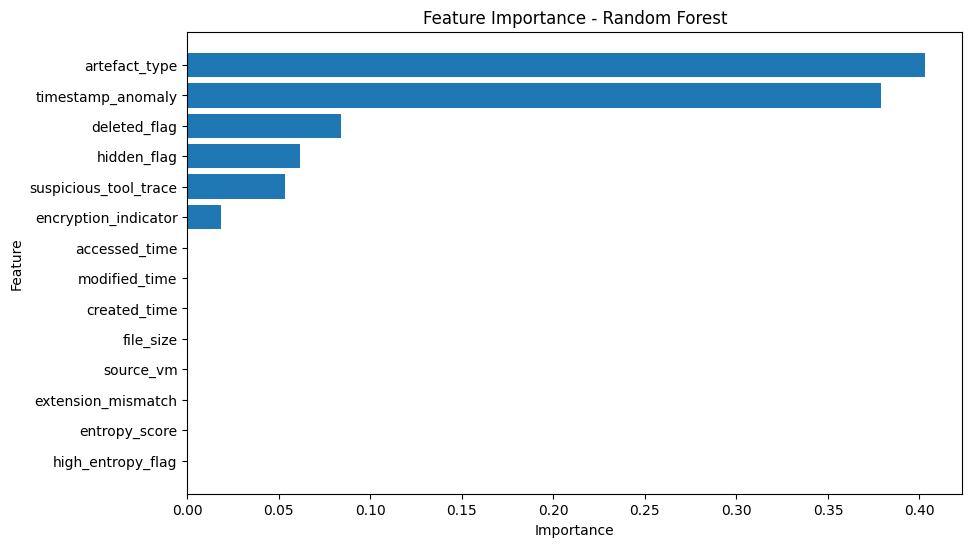

In [ ]:
# Chart It

feature_importance = pd.DataFrame({
    "feature": x.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
#Dataset Validation
df = pd.read_csv("Capstone_Final_Dataset_with_entropy.csv")

print("Dataset shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nLabel counts:")
print(df["label"].value_counts())

print("\nArtefact types:")
print(df["artefact_type"].value_counts())

Dataset shape: (87, 18)

Columns:
['source_vm', 'artefact_type', 'file_name', 'file_path', 'file_size', 'created_time', 'modified_time', 'accessed_time', 'deleted_flag', 'hidden_flag', 'extension_mismatch', 'timestamp_anomaly', 'suspicious_tool_trace', 'encryption_indicator', 'notes', 'label', 'entropy_score', 'high_entropy_flag']

Label counts:
label
0    55
1    32
Name: count, dtype: int64

Artefact types:
artefact_type
deleted_file       27
exe_file           18
image_file         14
html_file          14
office_document     5
pdf_document        5
archive             4
Name: count, dtype: int64


In [ ]:
#Entropy Calculation
entropy_df
print(entropy_df[["file_name", "dataset", "entropy_score", "high_entropy_flag"]])

                                            file_name dataset  entropy_score  \
0                           74141-orange frog.png.png   clean         7.9886   
1                                 animation.html.html   clean         4.3712   
2                       74137-kermit the frog.png.png   clean         7.9880   
3                            74135-green frog.png.png   clean         7.9934   
4                        74145-save the frogs.png.png   clean         7.9935   
5                            74133-glass frog.png.png   clean         7.9917   
6   tm02835233[[fn=text sidebar (annual report red...   clean         6.4233   
7   all work and no play make jack a dull boy.docx...   clean         7.2076   
8                       mpdefendercoreservice.exe.exe   clean        -0.0000   
9                            74129-drama frog.png.png   clean         7.9888   
10                          74143-purple frog.png.png   clean         7.9955   
11                      74151-yell-black

In [ ]:
#Model Training
print("Training rows:", len(x_train))
print("Test rows:", len(x_test))
print("Features used:")
print(x.columns.tolist())

Training rows: 60
Test rows: 27
Features used:
['source_vm', 'artefact_type', 'file_size', 'created_time', 'modified_time', 'accessed_time', 'deleted_flag', 'hidden_flag', 'extension_mismatch', 'timestamp_anomaly', 'suspicious_tool_trace', 'encryption_indicator', 'entropy_score', 'high_entropy_flag']


In [ ]:
#Classification Report
print("Classification Report:")
print(classification_report(y_test, y_pred))

Classification Report:
              precision    recall  f1-score   support

           0       1.00      0.82      0.90        17
           1       0.77      1.00      0.87        10

    accuracy                           0.89        27
   macro avg       0.88      0.91      0.89        27
weighted avg       0.91      0.89      0.89        27



In [ ]:
#Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[14  3]
 [ 0 10]]


In [ ]:
#Forensic Triage Metrics

tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
precision = tp / (tp + fp)
recall = tp / (tp + fn)
fnr = fn / (fn + tp)
npv = tn / (tn + fn)
pr_auc = average_precision_score(y_test, y_prob)

print(f"Precision: {precision:.3f}")
print(f"Recall: {recall:.3f}")
print(f"False Negative Rate (FNR): {fnr:.3f}")
print(f"Negative Predictive Value (NPV): {npv:.3f}")
print(f"PR-AUC {pr_auc:.3f}")

Precision: 0.769
Recall: 1.000
False Negative Rate (FNR): 0.000
Negative Predictive Value (NPV): 1.000
PR-AUC 1.000


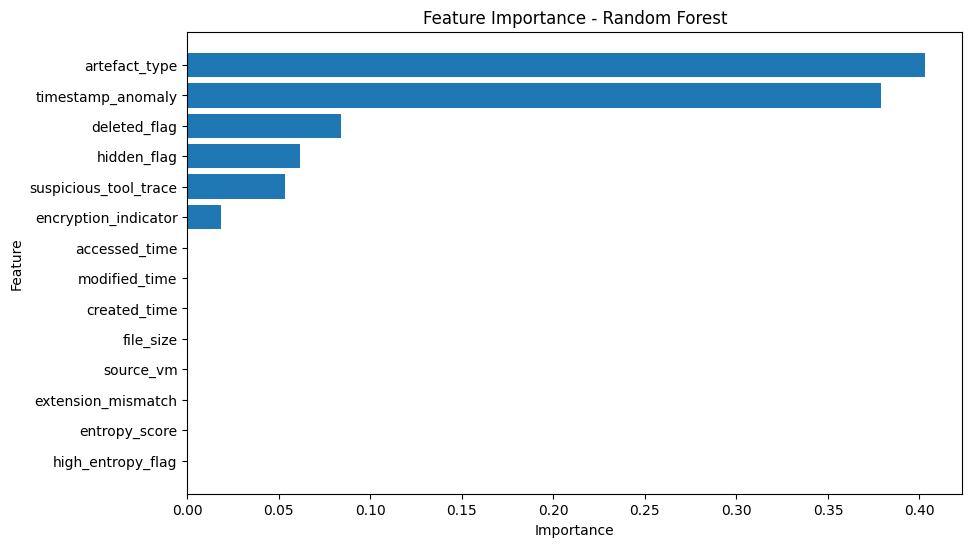

In [ ]:
#Feature Importance
feature_importance = pd.DataFrame({
    "feature": x.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance

#Chart
plt.figure(figsize=(10, 6))
plt.barh(feature_importance["feature"], feature_importance["importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - Random Forest")
plt.gca().invert_yaxis()
plt.show()

Following the above pipeline a light version of the Cyber Kiosk used by Police Scotland.
1. Imports at top of work book
2. Create Cyber Kiosk
3. Run pipeline and Kiosk together
4. Provide graphics


In [ ]:
# Cyber Kisok Light

def cyber_kiosk():
  print("\n --- Cyber Kiosk (Prototype) ---")
  print("Enter feature values\n")

  user_input = {}

  for feature in x.columns:
    try:
      value = float(input(f"{feature}: "))
    except:
      value = 0
    user_input[feature] = value

  input_df = pd.DataFrame([user_input])

  prediction = model.predict(input_df)[0]
  probability = model.predict_proba(input_df)[0][1]

  print("\n---Result---")

  threshold = 0.7
  if probability >= threshold:
    print("!! Suspicious Activity Detected !!")
  else:
    print("*** No Suspicious Activity Detected ***")


In [ ]:
print(x.shape)

(87, 14)


In [ ]:
#test above

cyber_kiosk()


 --- Cyber Kiosk (Prototype) ---
Enter feature values

source_vm: 1
artefact_type: 2
file_size: 5
created_time: 1
modified_time: 5
accessed_time: 
deleted_flag: 2
hidden_flag: 5
extension_mismatch: 1
timestamp_anomaly: 
suspicious_tool_trace: 2
encryption_indicator: 5
entropy_score: 5.5
high_entropy_flag: 2

---Result---
!! Suspicious Activity Detected !!
